In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve

# Models
from xgboost import XGBClassifier
from tensorflow.keras import models, layers, callbacks, optimizers

In [ ]:
path = "../data/BankChurners.csv"
df = pd.read_csv(path)

In [5]:
df['Attrition_Flag'] = df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0) 

In [ ]:
X = df.drop(columns=['CLIENTNUM', 'Attrition_Flag']) 
y = df['Attrition_Flag']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y 
)

In [ ]:
edu_cat = [["Uneducated", "Unknown", "High School", "College", "Graduate", "Post-Graduate", "Doctorate"]] 
income_cat = [["Unknown", "Less than $40K", "$40K - $60K", "$60K - $80K", "$80K - $120K", "$120K +"]]

preprocessor = ColumnTransformer(
    transformers=[
        ("OHE", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), 
         ["Gender", "Marital_Status", "Card_Category"]), #[cite: 1]
        ("scale", StandardScaler(), 
         ["Customer_Age", "Dependent_count", "Months_on_book", "Total_Relationship_Count", #[cite: 1]
          "Months_Inactive_12_mon", "Contacts_Count_12_mon", "Credit_Limit", "Total_Revolving_Bal", #[cite: 1]
          "Avg_Open_To_Buy", "Total_Amt_Chng_Q4_Q1", "Total_Trans_Amt", "Total_Trans_Ct", #[cite: 1]
          "Total_Ct_Chng_Q4_Q1", "Avg_Utilization_Ratio"]), #[cite: 1]
        ("edu_ord", OrdinalEncoder(categories=edu_cat), ["Education_Level"]), #[cite: 1]
        ("inc_ord", OrdinalEncoder(categories=income_cat), ["Income_Category"]), #[cite: 1]
    ],
    remainder="passthrough" 
)

In [10]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

In [11]:
print("--- Training XGBoost Baseline ---")


pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=pos_weight,
    eval_metric="aucpr",
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)
xgb_preds = xgb_model.predict(X_test_processed)
xgb_probs = xgb_model.predict_proba(X_test_processed)[:, 1]

--- Training XGBoost Baseline ---


In [12]:
print("\nXGBoost Performance:")
print(classification_report(y_test, xgb_preds))
print(f"XGB ROC-AUC: {roc_auc_score(y_test, xgb_probs):.4f}")


XGBoost Performance:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       850
           1       0.85      0.94      0.89       163

    accuracy                           0.96      1013
   macro avg       0.92      0.95      0.94      1013
weighted avg       0.97      0.96      0.96      1013

XGB ROC-AUC: 0.9931


In [ ]:
print("\n--- Training Deep Neural Network ---")


class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train) 
weights_dict = dict(enumerate(class_weights)) 

nn_model = models.Sequential([ 
    layers.Input(shape=(X_train_processed.shape[1],)), 
    layers.Dense(64, activation='relu'), 
    layers.BatchNormalization(), 
    layers.Dropout(0.4), 
    layers.Dense(32, activation='relu'), 
    layers.BatchNormalization(), 
    layers.Dropout(0.2), 
    layers.Dense(8, activation='relu'), 
    layers.BatchNormalization(), 
    layers.Dropout(0.1), 
    layers.Dense(1, activation='sigmoid') 
])


--- Training Deep Neural Network ---


W0000 00:00:1789135914.014599  379967 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [15]:
nn_model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy']) 

earlystopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True) 
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, min_lr=1e-5) 

history = nn_model.fit(
    X_train_processed, y_train, 
    validation_data=(X_test_processed, y_test), 
    class_weight=weights_dict, 
    epochs=50, 
    batch_size=32,
    callbacks=[earlystopping, reduce_lr], 
    verbose=0 
)

In [17]:
nn_probs = nn_model.predict(X_test_processed).flatten()

precision, recall, thresholds = precision_recall_curve(y_test, nn_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

nn_preds = (nn_probs >= best_threshold).astype(int)
print(f"\nNeural Network Performance (Threshold = {best_threshold:.2f}):")
print(classification_report(y_test, nn_preds))
print(f"NN ROC-AUC: {roc_auc_score(y_test, nn_probs):.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Neural Network Performance (Threshold = 0.64):
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       850
           1       0.77      0.87      0.82       163

    accuracy                           0.94      1013
   macro avg       0.87      0.91      0.89      1013
weighted avg       0.94      0.94      0.94      1013

NN ROC-AUC: 0.9718



--- Generating SHAP Explanations ---


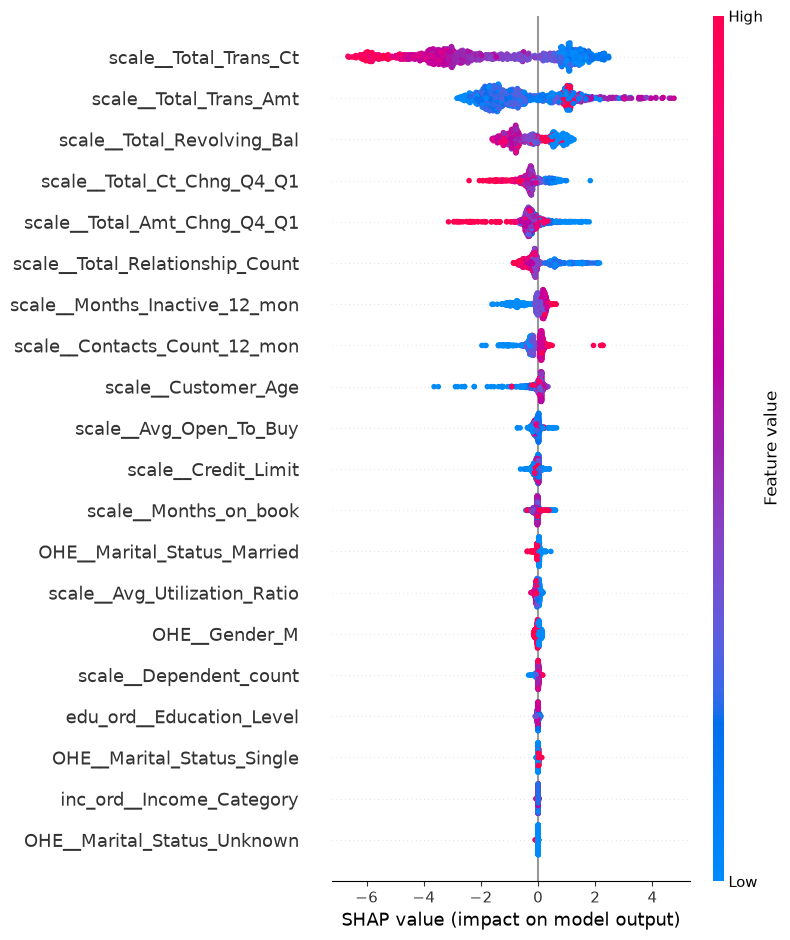

In [19]:
print("\n--- Generating SHAP Explanations ---")
# Using TreeExplainer instead of KernelExplainer for massive speed and scalability improvements
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_processed)

# Plot summary to understand global feature importance and directionality
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names)

In [ ]:
import joblib
joblib.dump(preprocessor, "../models/preprocessor.joblib")
xgb_model.save_model("../models/xgb_churn_model.json")